# Unsupervised Learning on Country Data

## Objective
The objective of this project is to cluster countries based on socio-economic and health indicators using unsupervised machine learning techniques. The clusters will help HELP International identify countries that require financial aid and support.

## Algorithms Used
- K-Means Clustering
- Hierarchical Clustering
- Principal Component Analysis (PCA)

## Libraries Used
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [23]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

# Loading the Dataset

The dataset is loaded from the Kaggle input directory.

In [10]:
df = pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Dataset Overview

Understanding the dimensions and structure of the dataset.

In [24]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (167, 10)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


# Missing Values

Checking whether the dataset contains any missing values.

In [13]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

# Duplicate Records

Checking for duplicate rows in the dataset.

In [26]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Exploratory Data Analysis (EDA)

Visualizing the distribution of variables and identifying relationships.

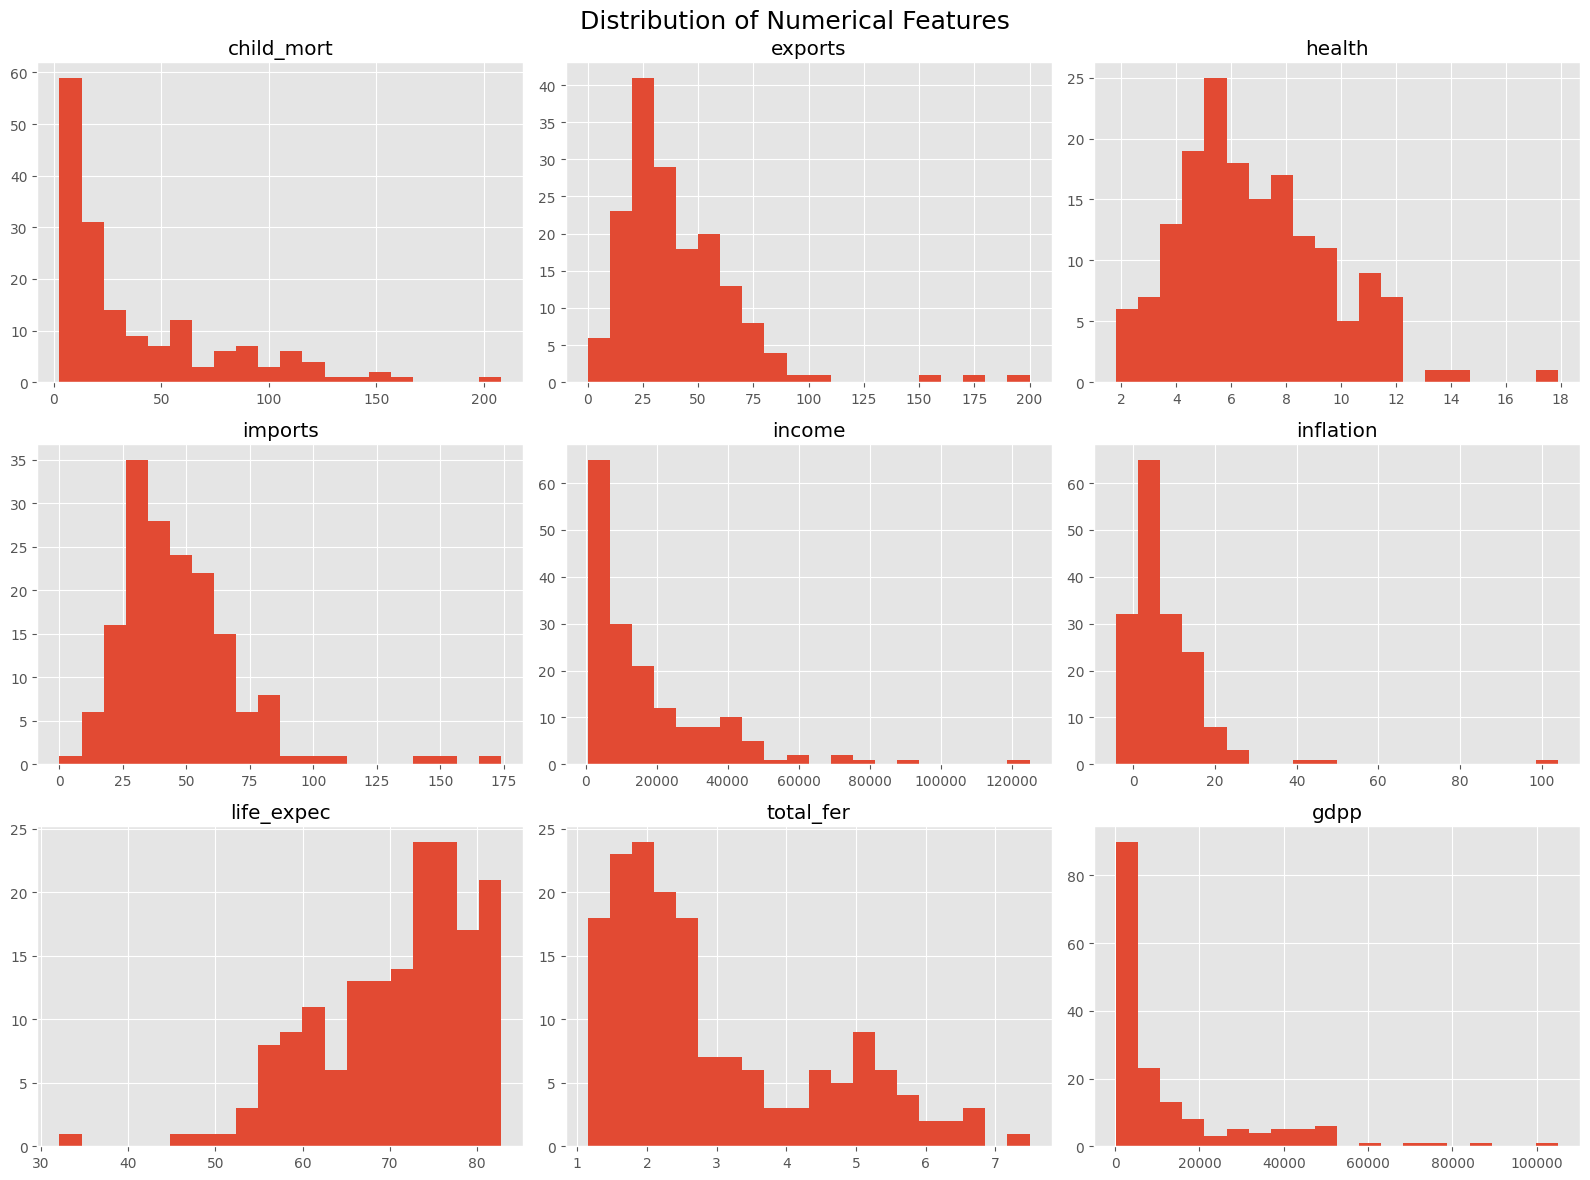

In [27]:
df.drop('country', axis=1).hist(figsize=(16,12), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.tight_layout()

plt.show()

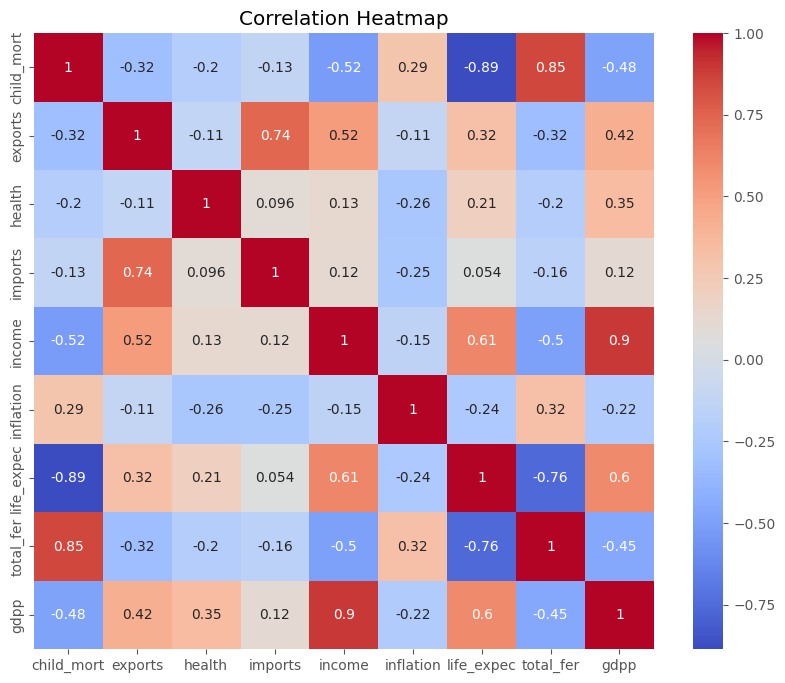

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(df.drop('country', axis=1).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

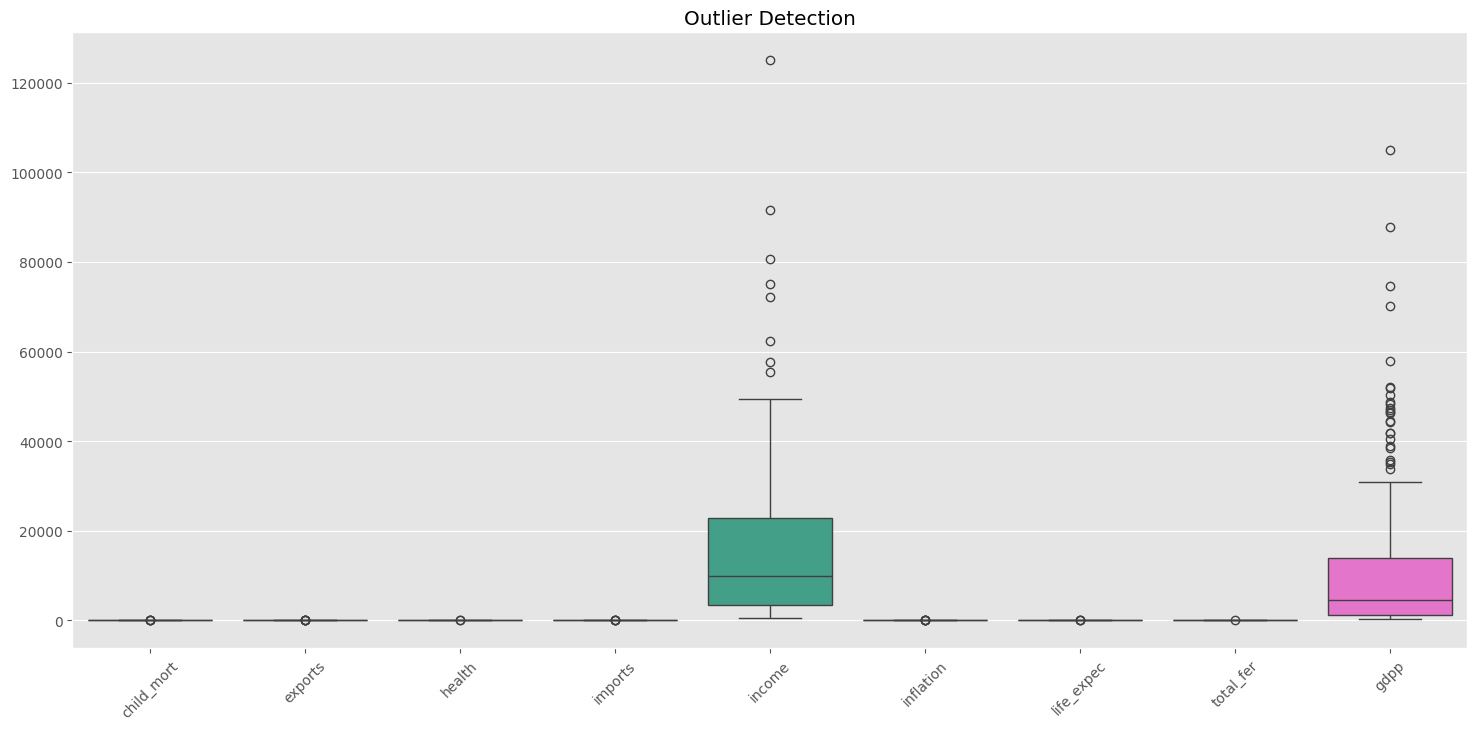

In [29]:
plt.figure(figsize=(18,8))

sns.boxplot(data=df.drop('country',axis=1))

plt.xticks(rotation=45)

plt.title("Outlier Detection")

plt.show()

# Data Preprocessing

The country names are removed since they are categorical. Numerical features are standardized before clustering.

In [30]:
countries = df['country']

X = df.drop('country', axis=1)

In [31]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Finding the Optimal Number of Clusters

The Elbow Method helps determine the appropriate number of clusters.

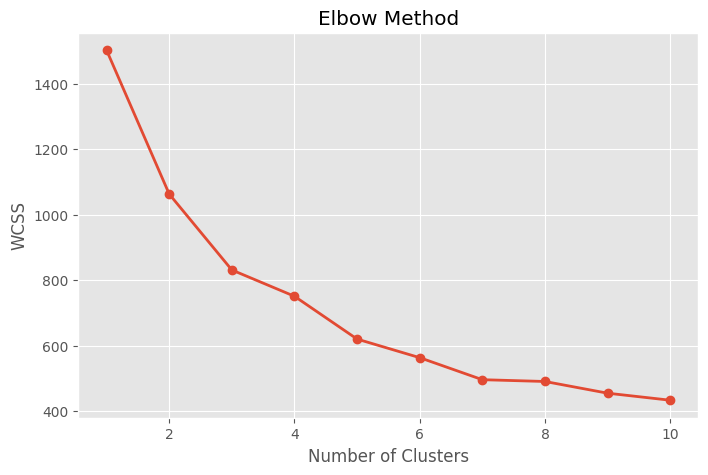

In [32]:
wcss = []

for i in range(1,11):

    model = KMeans(n_clusters=i,
                   random_state=42)

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o',
         linewidth=2)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# Silhouette Score

The Silhouette Score measures the quality of clustering. Higher values indicate better-defined clusters.

In [33]:
for i in range(2,8):

    labels = KMeans(n_clusters=i,
                    random_state=42).fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"Clusters = {i}  --> Silhouette Score = {score:.3f}")

Clusters = 2  --> Silhouette Score = 0.266
Clusters = 3  --> Silhouette Score = 0.286
Clusters = 4  --> Silhouette Score = 0.288
Clusters = 5  --> Silhouette Score = 0.301
Clusters = 6  --> Silhouette Score = 0.236
Clusters = 7  --> Silhouette Score = 0.248


# K-Means Clustering

Based on the Elbow Method and Silhouette Score, the dataset is clustered into three groups.

In [34]:
kmeans = KMeans(n_clusters=3,
                random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster Sizes

In [35]:
df['Cluster'].value_counts()

Cluster
0    86
2    45
1    36
Name: count, dtype: int64

# Cluster Summary

In [36]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


# Principal Component Analysis (PCA)

PCA reduces the dimensions of the dataset, allowing visualization of clusters in two dimensions.

In [38]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

In [39]:
pca_df = pd.DataFrame(pca_data,
                      columns=['PC1','PC2'])

pca_df['Cluster'] = df['Cluster']

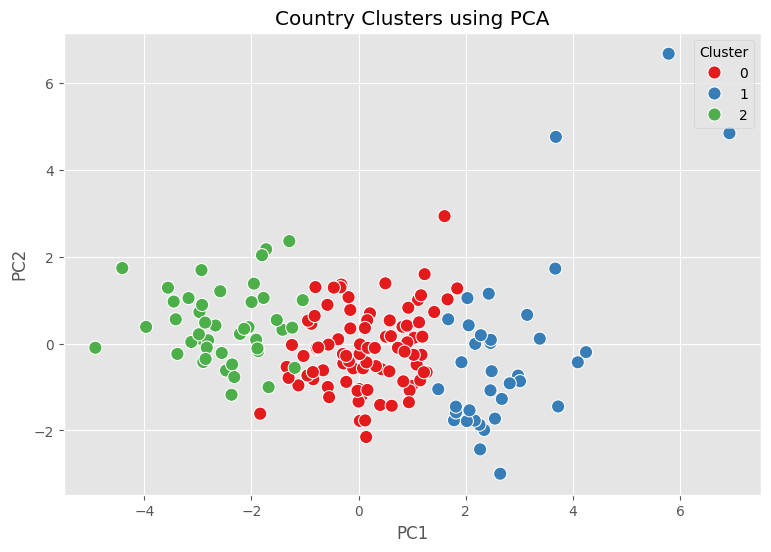

In [40]:
plt.figure(figsize=(9,6))

sns.scatterplot(data=pca_df,
                x='PC1',
                y='PC2',
                hue='Cluster',
                palette='Set1',
                s=90)

plt.title("Country Clusters using PCA")

plt.show()

# Hierarchical Clustering

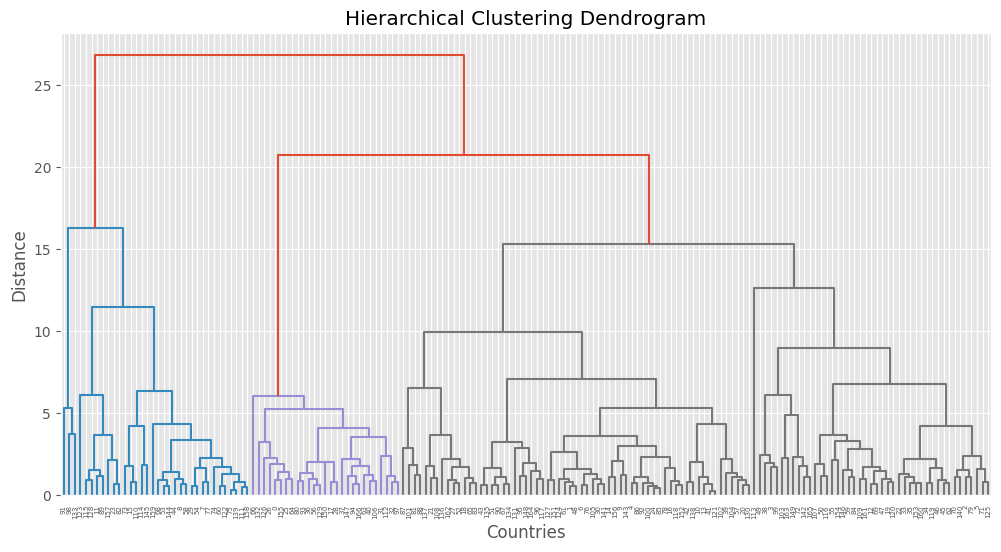

In [41]:
plt.figure(figsize=(12,6))

dendrogram(linkage(X_scaled,
                   method='ward'))

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Countries")

plt.ylabel("Distance")

plt.show()

In [42]:
hc = AgglomerativeClustering(n_clusters=3)

df['HC_Cluster'] = hc.fit_predict(X_scaled)

In [43]:
df.groupby("HC_Cluster").mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
HC_Cluster,,,,,,,,,,
0,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235,0.911765
1,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925,0.386792
2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889,2.000000


# Countries Requiring Maximum Aid

Countries with low GDP, low income, low life expectancy, and high child mortality are considered the highest priority for financial aid.

In [44]:
priority_cluster = cluster_summary.sort_values(
    by=['income', 'gdpp', 'life_expec'],
    ascending=[True, True, True]
).index[0]

priority_countries = df[df['Cluster'] == priority_cluster]

priority_countries[['country',
                    'income',
                    'gdpp',
                    'child_mort',
                    'life_expec']].sort_values(
                        by=['income', 'gdpp']
                    ).head(20)

,country,income,gdpp,child_mort,life_expec
37,"Congo, Dem. Rep.",609,334,116.0,57.5
88,Liberia,700,327,89.3,60.8
26,Burundi,764,231,93.6,57.7
112,Niger,814,348,123.0,58.8
31,Central African Republic,888,446,149.0,47.5
106,Mozambique,918,419,101.0,54.5
94,Malawi,1030,459,90.5,53.1
63,Guinea,1190,648,109.0,58.0
150,Togo,1210,488,90.3,58.7
132,Sierra Leone,1220,399,160.0,55.0


# Conclusion

- The dataset was successfully clustered using K-Means and Hierarchical Clustering.
- Three clusters were identified based on socio-economic and health indicators.
- PCA was used to visualize the clusters in two dimensions.
- The cluster with low income, low GDP per capita, low life expectancy, and high child mortality represents the countries requiring the highest priority for financial aid.
- HELP International can use these insights to allocate resources more effectively.